# Assignment 8 - Particle Filtering

**Name**:Taniya Haghighi

**Student ID**:

### Import the required packages
You are to implement the algorithms yourself and forbided from the use of dedicated packages!

In [1]:
import numpy as np
import random 
import math
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D
from scipy.stats import norm

### Load input data
`input.txt` contains a sample log of vahid's location and `ground_truth.txt` holds the initial state and the hidden state's correrct location at each time-frame, employ it to validate your findings.

In [2]:
with open('input.txt', 'r') as file:
    n, k, mean_pace, t = file.readline().split(' ')
    n, t, k, mean_pace = int(n), int(t), float(k), float(mean_pace)
    sen_error_mean, sen_error_std, sen_xs, sen_ys = list(), list(), list(), list()
    for i in range(n):
        x,y, mu, sig = map(float, file.readline().split(' '))
        sen_xs.append(x)
        sen_ys.append(y)
        sen_error_mean.append(mu)
        sen_error_std.append(sig)
    sen_error_mean = np.array(sen_error_mean)
    sen_error_std = np.array(sen_error_std)
    sens = np.stack([np.array(sen_xs), np.array(sen_ys)], axis=1)
    gt_distances = [np.array(list(map(float, file.readline().split(' ')))) for i in range(t)]
with open('ground_truth.txt', 'r') as file:
    ground_truth = [np.array(list(map(float, line.split(' ')))) for line in  file.readlines()]

    


### Implement utility functions
Implement the utility functions required for particle filtering (the following strucutre is merely a suggestion and you can choose to discard it).

In [3]:
def move(particles: np.array, mean_pace_t: float):
    "sample the next time-frame coordinates"
    # for you to implement
    theta =random.randint(0, 360)
    theta = np.deg2rad(theta)

    particles=particles+[np.cos(theta)*mean_pace_t,np.sin(theta)*mean_pace_t]
        
    # update the mean_pace_t
    mean_pace_t*=k
    return particles, mean_pace_t

In [4]:
def get_distances(particles: np.array, sensors: np.array):
    "utility function to calculate particle distances from sensors"
    # for you to implement
    
    evidence_distances=[]
    # for each particle you need to find its distance to all 7 sensors, for example if you have 1000 particles,
    # the shape of evidence_distances would be (1000, 7). 
    # Each particle and each sensor has a location which is a 2-dimensional array. You need to find the euclidean 
    # distance between them
    
    for particle in particles:
        distance=[]
        for sensor in sensors:
            distance.append(np.linalg.norm(particle-sensor))
        evidence_distances.append(distance)
        
    evidence_distances = np.array(evidence_distances)
    return evidence_distances

In [5]:
def get_weights(evidence_distances:np.array, gt_distances:np.array, sen_error_mean:np.array, sen_error_std:np.array):
    "utility function to calculate distance likelihoods"
    # for you to implement
    
    likelihoods = []
    for i in range(evidence_distances.shape[0]):
        # for each particle, you calculated 7 distance. You need to find their likelihoods 
        # You must use the a suitable probability density function for calculating the likelihood of distances. Notice 
        # that the distances has noises. Read that part of the assignment carefully. 
        # The likelihoods of distances whose differances to the ground truth distances is smaller must have larger 
        # likelihoods.

        dists=abs(gt_distances-evidence_distances[i])
        
        for j in range(evidence_distances.shape[1]):
            dists[j]=norm(sen_error_mean[j], sen_error_std[j]).pdf(dists[j])
        
        likelihoods.append(dists)
    
    likelihoods = np.array(likelihoods)
#     print(likelihoods[:10])
    # Now you have 7 likelihoods for each particle. Use them to calculate one weight for each particle. 
    # Sum of weights must be 1
    #     just to avoid zero sum of rows
    likelihoods+=0.00001
    mul_of_rows=np.prod(likelihoods,axis=1)
#     print("---")
#     print(mul_of_rows[:10])

    weights=mul_of_rows/np.sum(mul_of_rows)
    weights=np.array(weights)
    return weights



In [6]:
def resample(weights:np.array, particles:np.array):
    "utility function to resample particles"
    # for you to implement
    number_of_particles=1000
    # You need to selet among the particles. If you have 1000 particles, you must select 1000 particles among them.
    # But this selection is based on the weight of the particles, if weight of a particles. This is called resampling.
    # Save and return the selected particles in "resampled" array.
    resampled =particles[np.random.choice(number_of_particles, number_of_particles, replace=True,p=weights), :]
    
    return resampled

## A. Particle Filtering

In [7]:
# for you to implement
number_of_particles = 1000
std_log = []
particles_log = []
mean_pace_t = mean_pace 


# particles = [np.random.randint(200,size=2) for i in range(number_of_particles)]# start with random particles in the jungle (200*200 square).
particles =[np.random.uniform(low=0.0, high=200.0, size=2)for i in range(number_of_particles)]
particles =np.array(particles)
error_log = [np.mean(np.abs(ground_truth[0] - particles))]
position_log = [np.mean(particles,axis=0)]

# print(f'particles={particles}')
for i in range(t):
    if i%10 ==0: print(i)
    # execute the particle filtering process with use of the functions you have completed.
    
    evidence_distances=get_distances(particles, sens)
    weights=get_weights(evidence_distances, gt_distances[i], sen_error_mean, sen_error_std)
    particles=resample(weights, particles)
    particles, mean_pace_t=move(particles, mean_pace_t)
    
    # save logs
    error_log.append(np.mean(np.abs(ground_truth[i] - particles)))
    std_log.append(np.std(particles,axis=0))
    position_log.append(np.mean(particles,axis=0))

0
10
20
30
40
50


In [8]:
print('ground truth', *ground_truth[-1])
print('finding', *position_log[-1])

ground truth 131.62252381461028 123.0757221368539
finding 126.67293577274563 90.12717537245639


Elaborate on why your findings vary from the ground truth? (if they do)

i tried to underestand the reason by debugging and even asked the teacher for help but we couldn't find the reason right away.

## B. Plot your trajectory prediction and other plots

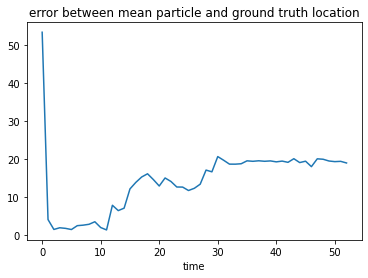

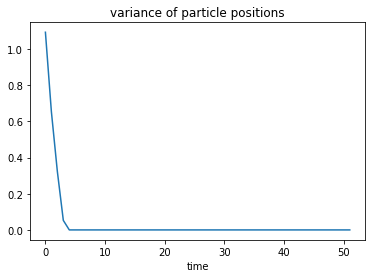

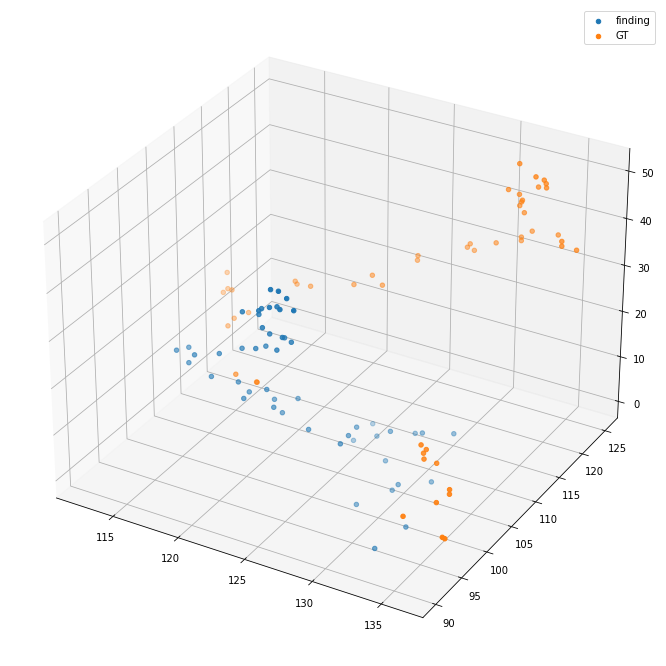

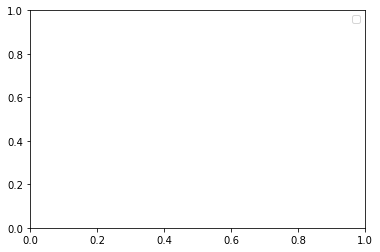

In [9]:
# for you to implement
# plot the error_log
# plot std_log
# plot the trajectory of the real path and your predicted path



plt.title("error between mean particle and ground truth location")
plt.xlabel("time")

# x = [datetime.datetime.now() + datetime.timedelta(hours=i) for i in range(12)]
# y = [i+random.gauss(0,1) for i,_ in enumerate(x)]
# plt.plot(x,y)


x=[i for i in range(len(error_log))]
plt.plot(x ,error_log)
plt.show()

###################################################################
 
plt.title("variance of particle positions")
plt.xlabel("time")
x= [i for i in range(len(std_log))]
y=np.mean(std_log,axis=1)
plt.plot(x,y)
plt.show()

###################################################################

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
# print(f'position_log={position_log}')
pl=list(zip(*position_log))
pl=np.array(pl)
ground_truth=np.array(ground_truth)
# print(f'position_log={pl.shape}')
x1 = pl[0,1:]
y1 = pl[1,1:]
x2 = ground_truth[:,0]
y2 = ground_truth[:,1]
z=[i for i in range(ground_truth.shape[0])]
# print(f'x1={x1.shape[0]}')
# print(f'y1={y1.shape[0]}')
# print(f'x2={x2.shape[0]}')
# print(f'y2={y2.shape[0]}')
# print(f'z={len(z)}')
ax.scatter(x1, y1, z, label='finding')
ax.scatter(x2, y2, z, label='GT')

plt.legend()
plt.show()


plt.legend(["particle filter","ground truth"])



Provide a short analysis of all resulted graphs.

the third 3D chart shows the path that we think Vahid went through and the actual one. if the particlees are close to the ground-truth then we know we have predicted the path correctly(maybe not exactly) and the error will be small.

the first chart shows the mean location of particles and the actual location of Vahid. if the chart decreases it means that the particles are predicting Vahid's location better and we can estimate where he is by the mean of particles.

the second chart shows the variance of particle locations. at first when we don't have so many clues about the location of Vahid, the variance is much more than when we get some evidences and predict where he is based on them. so, variance of particles should decrease as time passes.

## C. Analysis of different k values
Briefly explain what values of $k$ would eventually lead to better predictions?

when we choose a small k then the difference between mean of particle positions (in position_log) reduces. this means we cannot find the right location of vahid if his actual k is larger(it means he can run faster but we think that he runs with a small k). so we need to run the iterations with right value for k to estimate his location.